In [6]:
import sys 
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sim.rl import TrackingEnv

In [7]:
from stable_baselines3.common.env_checker import check_env
check_env(TrackingEnv())

Train and chcek the results of the PPO model if not go
 SAC(PPO experimental - 1_000_000, 700_000
 )

In [8]:
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

env = Monitor(TrackingEnv(), "../results/ppo_train")
ppo = PPO("MlpPolicy", env, seed=0, verbose=1)
ppo.learn(total_timesteps=700_000)
ppo.save("../results/ppo_tracking")

Using cpu device
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 1e+03     |
|    ep_rew_mean     | -6.21e+03 |
| time/              |           |
|    fps             | 6230      |
|    iterations      | 1         |
|    time_elapsed    | 0         |
|    total_timesteps | 2048      |
----------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 779          |
|    ep_rew_mean          | -5.31e+03    |
| time/                   |              |
|    fps                  | 3857         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0036981974 |
|    clip_fraction        | 0.0163       |
|    clip_range           | 0.2          |
|    entropy_loss         | -4.26      

Train the SAC model check the results (SAC experimental  - 300_000, 600_000)

In [ ]:
from stable_baselines3 import SAC

env = Monitor(TrackingEnv(), "../results/sac_train")
sac = SAC("MlpPolicy", env, seed=0, verbose=1)
sac.learn(total_timesteps=600_000)
sac.save("../results/sac_tracking")

Using cpu device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 672      |
|    ep_rew_mean     | -4.5e+03 |
| time/              |          |
|    episodes        | 4        |
|    fps             | 233      |
|    time_elapsed    | 11       |
|    total_timesteps | 2688     |
| train/             |          |
|    actor_loss      | 51.6     |
|    critic_loss     | 0.958    |
|    ent_coef        | 0.465    |
|    ent_coef_loss   | -3.57    |
|    learning_rate   | 0.0003   |
|    n_updates       | 2587     |
---------------------------------
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 693       |
|    ep_rew_mean     | -5.02e+03 |
| time/              |           |
|    episodes        | 8         |
|    fps             | 228       |
|    time_elapsed    | 24        |
|    total_timesteps | 5546      |
| train/             |           |
|    actor_loss     

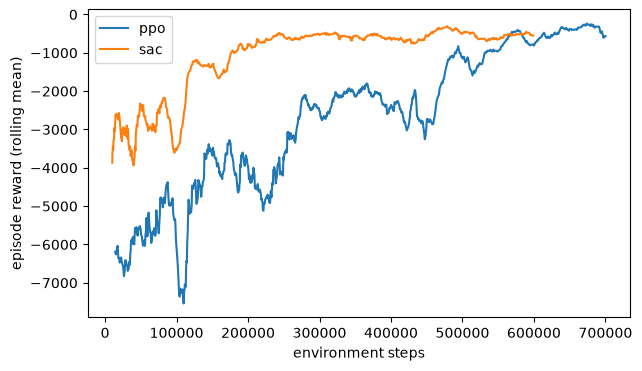

In [20]:
fig, ax = plt.subplots(figsize=(7,4))
for name in ["ppo", "sac"]:
    log = pd.read_csv(f"../results/{name}_train.monitor.csv", skiprows=1)
    ax.plot(np.cumsum(log["l"]), log["r"].rolling(20).mean(), label=name)
ax.set(xlabel="environment steps", ylabel="episode reward (rolling mean)")
ax.legend()    


In [22]:
from controllers.rl import RlController
from sim.runner import run_tracking, tracking_metrics
from sim.trajectories import circle_ref, figure8_ref, waypoint_ref

runs = [
    ("circle", circle_ref, 40.0),
    ("figure8", figure8_ref, 60.0),
    ("waypoints", lambda t: waypoint_ref(t, hold=8.0), 40.0),
]
rows = []
for algo in ["ppo", "sac"]:
    ctrl = RlController(f"../results/{algo}_tracking", algo)
    for name, ref_fn, duration in runs:
        res = run_tracking(ctrl, ref_fn, duration)
        rows.append({"controller": algo, "trajectory": name, **tracking_metrics(res)})

df = pd.DataFrame(rows)
df.to_csv("../results/rl_nominal.csv", index=False)
df


,controller,trajectory,pos_rmse,heading_rmse,effort,compute_ms_mean,compute_ms_max
0,ppo,circle,0.200273,0.161794,12831.411444,0.099653,24.334042
1,ppo,figure8,0.169622,0.121150,18032.382224,0.075328,0.186709
2,ppo,waypoints,0.973658,0.408086,58069.020921,0.079605,0.258875
3,sac,circle,0.504887,0.051507,15001.458097,0.118102,0.557541
4,sac,figure8,0.477332,0.458775,61359.633126,0.116832,0.257167
5,sac,waypoints,0.826827,0.219795,70339.601549,0.116328,0.192500


In [23]:
combined = pd.concat([pd.read_csv(f"../results/{c}_nominal.csv") for c in ["pid", "mpc", "rl"]])
combined.sort_values(["trajectory", "controller"])


,controller,trajectory,pos_rmse,heading_rmse,effort,compute_ms_mean,compute_ms_max
0,mpc,circle,0.045107,1.117092e-02,14900.833860,2.737632,39.105875
0,pid,circle,0.301985,1.442013e-01,16307.545806,0.010444,0.879125
0,ppo,circle,0.200273,1.617945e-01,12831.411444,0.099653,24.334042
3,sac,circle,0.504887,5.150707e-02,15001.458097,0.118102,0.557541
1,mpc,figure8,0.032075,7.560366e-03,11912.105294,2.651914,22.721667
1,pid,figure8,0.188251,1.395273e-01,12955.661897,0.008808,0.082208
1,ppo,figure8,0.169622,1.211500e-01,18032.382224,0.075328,0.186709
4,sac,figure8,0.477332,4.587755e-01,61359.633126,0.116832,0.257167
2,mpc,waypoints,0.216489,1.200614e-04,39837.221490,2.819423,21.689250
2,pid,waypoints,0.658036,2.281976e-16,11510.396359,0.008802,0.042791


In [24]:
log = pd.read_csv("../results/sac_train.monitor.csv", skiprows=1)
print(len(log), "episodes,", int(log["l"].sum()), "total steps")


686 episodes, 599173 total steps
